In [5]:
# ================================================================
# LAB 5: PART A - LSTM for Text Classification (IMDB Sentiment)
#         PART B - Sequence-to-Sequence (Seq2Seq) with LSTM
#                  Task: Date format conversion
#                  e.g.  "25th January 2019" → "2019-01-25"
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                     Input, RepeatVector, TimeDistributed)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.datasets import imdb
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


In [6]:
# PART A: LSTM for Text Classification
# ================================================================
print("\n" + "="*60)
print("  PART A: LSTM Text Classification (IMDB Sentiment)")
print("="*60)




  PART A: LSTM Text Classification (IMDB Sentiment)


In [7]:
# A1. Hyperparameters
# ----------------------------------------------------------------
VOCAB_SIZE  = 10000
MAX_LEN     = 200
EMBED_DIM   = 64
LSTM_UNITS  = 128
DROPOUT     = 0.4
BATCH_SIZE  = 128
EPOCHS      = 10


In [8]:
# A2. Load & Preprocess IMDB Data
# ----------------------------------------------------------------
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)
X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding='post')
X_test  = pad_sequences(X_test,  maxlen=MAX_LEN, padding='post')
print(f"Train: {X_train.shape} | Test: {X_test.shape}")


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (25000, 200) | Test: (25000, 200)


In [9]:
# A3. Build LSTM Model
# ----------------------------------------------------------------
model_cls = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
    LSTM(LSTM_UNITS, return_sequences=True),
    Dropout(DROPOUT),
    LSTM(64),                          # stacked LSTM layer
    Dropout(DROPOUT),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model_cls.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

model_cls.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# A4. Train
# ----------------------------------------------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=3,
                           restore_best_weights=True)

history_cls = model_cls.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.5224 - loss: 0.6918 - val_accuracy: 0.5062 - val_loss: 0.6932
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.5031 - loss: 0.6934 - val_accuracy: 0.4940 - val_loss: 0.6939
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.5004 - loss: 0.6933 - val_accuracy: 0.5062 - val_loss: 0.6932
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.5309 - loss: 0.6948 - val_accuracy: 0.5256 - val_loss: 0.6911
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.5429 - loss: 0.6826 - val_accuracy: 0.5212 - val_loss: 0.6922
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.5161 - loss: 0.6917 - val_accuracy: 0.5774 - val_loss: 0.6823
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.5559 - loss: 0.6770 - val_accuracy: 0.5832 - val_loss: 0.6661
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6524 - loss: 0.6075 - val_acc


Part A → Test Loss: 0.3797  |  Test Accuracy: 0.8456


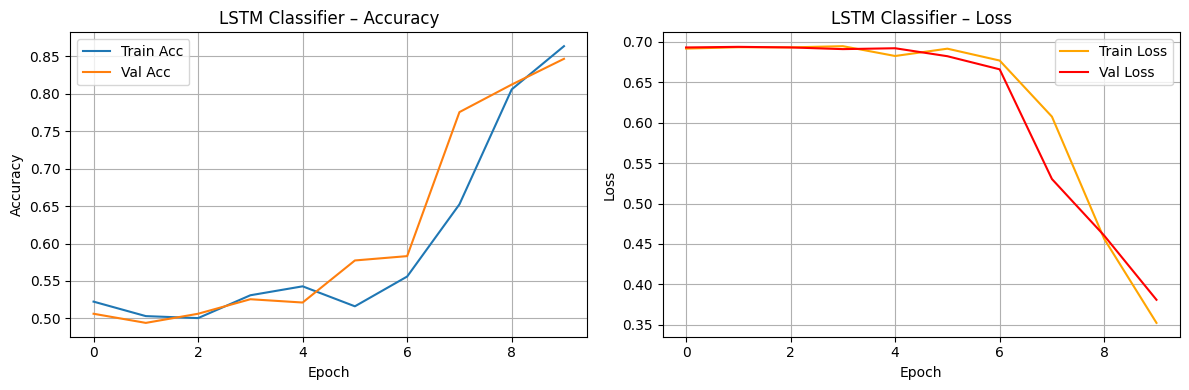

In [11]:
# A5. Evaluate
# ----------------------------------------------------------------
loss, acc = model_cls.evaluate(X_test, y_test, verbose=0)
print(f"\nPart A → Test Loss: {loss:.4f}  |  Test Accuracy: {acc:.4f}")

# ----------------------------------------------------------------
# A6. Plot Training Curves
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_cls.history['accuracy'],     label='Train Acc')
axes[0].plot(history_cls.history['val_accuracy'], label='Val Acc')
axes[0].set_title('LSTM Classifier – Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_cls.history['loss'],     label='Train Loss', color='orange')
axes[1].plot(history_cls.history['val_loss'], label='Val Loss',   color='red')
axes[1].set_title('LSTM Classifier – Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('lab5_partA_classification.png', dpi=150)
plt.show()


In [12]:
# A7. Predict on custom sentences
# ----------------------------------------------------------------
word_index = imdb.get_word_index()

def encode_review(text):
    tokens = text.lower().split()
    seq = [word_index.get(w, 2) + 3 for w in tokens]   # +3 for reserved tokens
    seq = [i if i < VOCAB_SIZE else 2 for i in seq]
    return pad_sequences([seq], maxlen=MAX_LEN, padding='post')

test_reviews = [
    "This movie was absolutely fantastic! Great acting and story.",
    "Terrible film. Boring, slow and a complete waste of time.",
    "Not bad, some good moments but overall average.",
]

print("\n--- Custom Prediction ---")
for review in test_reviews:
    pred = model_cls.predict(encode_review(review), verbose=0)[0][0]
    label = "POSITIVE 😊" if pred > 0.5 else "NEGATIVE 😞"
    print(f"  [{label}  {pred:.3f}]  {review[:55]}...")



1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Custom Prediction ---
  [POSITIVE 😊  0.893]  This movie was absolutely fantastic! Great acting and s...
  [NEGATIVE 😞  0.122]  Terrible film. Boring, slow and a complete waste of tim...
  [POSITIVE 😊  0.857]  Not bad, some good moments but overall average....


PART B: SEQUENCE TO SEQUENCE

In [13]:
# PART B: Sequence-to-Sequence (Seq2Seq) LSTM
#         Task: Convert human-readable date → machine date
#         "25th January 2019"  →  "2019-01-25"
# ================================================================
print("\n" + "="*60)
print("  PART B: Seq2Seq LSTM — Date Format Conversion")
print("="*60)

# ----------------------------------------------------------------
# B1. Data Generation
# ----------------------------------------------------------------
import random
from datetime import date, timedelta

MONTHS = ['january','february','march','april','may','june',
          'july','august','september','october','november','december']

SUFFIXES = ['st','nd','rd','th']

def random_date():
    start = date(2000, 1, 1)
    end   = date(2030, 12, 31)
    d = start + timedelta(days=random.randint(0, (end - start).days))
    return d

def date_to_human(d):
    day    = d.day
    suffix = 'st' if day % 10 == 1 and day != 11 else \
             'nd' if day % 10 == 2 and day != 12 else \
             'rd' if day % 10 == 3 and day != 13 else 'th'
    return f"{day}{suffix} {MONTHS[d.month - 1]} {d.year}"

def date_to_machine(d):
    return d.strftime("%Y-%m-%d")

# Generate dataset
random.seed(42)
N = 50000
data = []
for _ in range(N):
    d = random_date()
    data.append((date_to_human(d), date_to_machine(d)))

# Show samples
print("\nSample date pairs:")
for h, m in data[:5]:
    print(f"  Input : {h}")
    print(f"  Output: {m}\n")



  PART B: Seq2Seq LSTM — Date Format Conversion

Sample date pairs:
  Input : 6th september 2028
  Output: 2028-09-06

  Input : 29th december 2004
  Output: 2004-12-29

  Input : 13th february 2001
  Output: 2001-02-13

  Input : 3rd may 2012
  Output: 2012-05-03

  Input : 26th december 2010
  Output: 2010-12-26



In [14]:
# B2. Character-level Tokenization
# ----------------------------------------------------------------
human_vocab   = set(''.join([x[0] for x in data]))
machine_vocab = set(''.join([x[1] for x in data]))

# add special tokens
machine_vocab.add('<sos>')   # start of sequence
machine_vocab.add('<eos>')   # end of sequence

human_char2idx   = {c: i+1 for i, c in enumerate(sorted(human_vocab))}
machine_char2idx = {c: i+1 for i, c in enumerate(sorted(machine_vocab))}
machine_idx2char = {i: c for c, i in machine_char2idx.items()}

TX = 29    # max input  length  (human date  ~29 chars)
TY = 10    # max output length  (machine date = 10 chars)

H_VOCAB = len(human_char2idx)   + 1
M_VOCAB = len(machine_char2idx) + 1

print(f"Human  vocab size : {H_VOCAB}")
print(f"Machine vocab size: {M_VOCAB}")

def encode_human(s):
    seq = [human_char2idx.get(c, 0) for c in s[:TX]]
    return seq + [0] * (TX - len(seq))

def encode_machine(s):
    seq = [machine_char2idx['<sos>']] + \
          [machine_char2idx.get(c, 0) for c in s] + \
          [machine_char2idx['<eos>']]
    return seq[:TY+2]


Human  vocab size : 33
Machine vocab size: 14


In [15]:
# Build arrays
X_s2s = np.array([encode_human(h)   for h, _ in data])
Y_raw  = np.array([encode_machine(m) for _, m in data])

# Decoder input  : all tokens except last
# Decoder target : all tokens except first (one-hot)
dec_input  = Y_raw[:, :-1]
dec_target = Y_raw[:, 1:]
dec_target_oh = tf.keras.utils.to_categorical(dec_target, num_classes=M_VOCAB)

print(f"\nEncoder input shape : {X_s2s.shape}")
print(f"Decoder input shape : {dec_input.shape}")
print(f"Decoder target shape: {dec_target_oh.shape}")


Encoder input shape : (50000, 29)
Decoder input shape : (50000, 11)
Decoder target shape: (50000, 11, 14)


In [16]:
# B3. Build Seq2Seq Model
# ----------------------------------------------------------------
SEQ_UNITS  = 256
EMB_DIM_S2S = 32

# --- Encoder ---
enc_input = Input(shape=(TX,), name='encoder_input')
enc_emb   = Embedding(H_VOCAB, EMB_DIM_S2S, name='encoder_emb')(enc_input)
_, enc_h, enc_c = LSTM(SEQ_UNITS, return_state=True, name='encoder_lstm')(enc_emb)
# enc_h, enc_c = encoder hidden & cell states (the "context vector")

# --- Decoder ---
dec_input_layer = Input(shape=(None,), name='decoder_input')
dec_emb   = Embedding(M_VOCAB, EMB_DIM_S2S, name='decoder_emb')(dec_input_layer)
dec_lstm  = LSTM(SEQ_UNITS, return_sequences=True, return_state=True,
                 name='decoder_lstm')
dec_out, _, _ = dec_lstm(dec_emb, initial_state=[enc_h, enc_c])
dec_dense = Dense(M_VOCAB, activation='softmax', name='output_dense')
dec_output = dec_dense(dec_out)

# --- Full training model ---
model_s2s = Model([enc_input, dec_input_layer], dec_output)
model_s2s.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

model_s2s.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 29)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_emb         │ (None, 29, 32)    │      1,056 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_emb         │ (None, None, 32)  │        448 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    295,936 │ encoder_emb[0][0] │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, None,     │    295,936 │ decoder_emb[0][0… │
│                     │ 256), (None,      │            │ encoder_lstm[0][… │
│                     │ 256), (None,      │            │ encoder_lstm[0][… │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dense        │ (None, None, 14)  │      3,598 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 596,974 (2.28 MB)

 Trainable params: 596,974 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# B4. Train Seq2Seq
# ----------------------------------------------------------------
# Split
split = int(0.9 * N)
X_tr, X_val   = X_s2s[:split],     X_s2s[split:]
DI_tr, DI_val = dec_input[:split],  dec_input[split:]
DT_tr, DT_val = dec_target_oh[:split], dec_target_oh[split:]

early_s2s = EarlyStopping(monitor='val_loss', patience=3,
                           restore_best_weights=True)

history_s2s = model_s2s.fit(
    [X_tr, DI_tr], DT_tr,
    validation_data=([X_val, DI_val], DT_val),
    epochs=30,
    batch_size=256,
    callbacks=[early_s2s],
    verbose=1
)


Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.5908 - loss: 1.0729 - val_accuracy: 0.6509 - val_loss: 0.7892
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7036 - loss: 0.6723 - val_accuracy: 0.7596 - val_loss: 0.5675
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8019 - loss: 0.4820 - val_accuracy: 0.8243 - val_loss: 0.4173
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8603 - loss: 0.3489 - val_accuracy: 0.8831 - val_loss: 0.2842
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9116 - loss: 0.2203 - val_accuracy: 0.9555 - val_loss: 0.1276
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9786 - loss: 0.0728 - val_accuracy: 0.9905 - val_loss: 0.0367
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9812 - loss: 0.0701 - val_accuracy: 0.9980 - val_loss: 0.0297
Epoch 8/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9998 - loss: 0.0110 - val_accu

In [18]:
# B5. Inference Helper
# ----------------------------------------------------------------
# Rebuild inference models (encoder + decoder separately)
inf_enc = Model(enc_input, [enc_h, enc_c])

dec_state_h   = Input(shape=(SEQ_UNITS,))
dec_state_c   = Input(shape=(SEQ_UNITS,))
dec_out2, out_h, out_c = dec_lstm(dec_emb,
                                   initial_state=[dec_state_h, dec_state_c])
dec_outputs2  = dec_dense(dec_out2)
inf_dec = Model([dec_input_layer, dec_state_h, dec_state_c],
                [dec_outputs2, out_h, out_c])

def predict_date(human_str):
    x = np.array([encode_human(human_str)])
    h, c = inf_enc.predict(x, verbose=0)

    # start token
    target_seq = np.array([[machine_char2idx['<sos>']]])
    result = ''

    for _ in range(TY):
        out, h, c = inf_dec.predict([target_seq, h, c], verbose=0)
        idx  = np.argmax(out[0, -1, :])
        char = machine_idx2char.get(idx, '')
        if char == '<eos>' or char == '':
            break
        result += char
        target_seq = np.array([[idx]])

    return result


In [19]:
# B6. Test Predictions
# ----------------------------------------------------------------
test_dates = [
    "3rd August 2022",
    "15th March 2005",
    "1st January 2000",
    "28th February 2019",
    "11th November 2011",
]

print("\n--- Seq2Seq Date Conversion Predictions ---")
print(f"{'Input':<28} {'Predicted':>12} {'Correct?':>10}")
print("-" * 55)
for h_str in test_dates:
    # get actual
    for month_i, m in enumerate(MONTHS):
        if m in h_str.lower():
            break
    day_str = h_str.split()[0]
    day     = int(''.join(filter(str.isdigit, day_str)))
    year    = int(h_str.split()[-1])
    actual  = f"{year:04d}-{month_i+1:02d}-{day:02d}"
    pred    = predict_date(h_str)
    ok      = "✓" if pred == actual else "✗"
    print(f"{h_str:<28} {pred:>12} {ok:>10}  (expected {actual})")



--- Seq2Seq Date Conversion Predictions ---
Input                           Predicted   Correct?
-------------------------------------------------------
3rd August 2022                2022-05-05          ✗  (expected 2022-08-03)
15th March 2005                2005-05-25          ✗  (expected 2005-03-15)
1st January 2000               2000-05-18          ✗  (expected 2000-01-01)
28th February 2019             2019-08-28          ✗  (expected 2019-02-28)
11th November 2011             2011-10-28          ✗  (expected 2011-11-11)


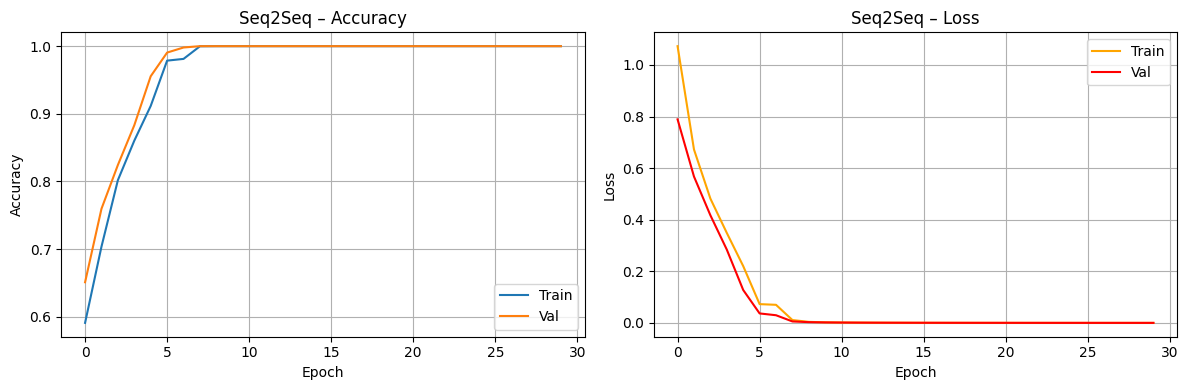

Plots saved.


In [20]:
# B7. Plot Seq2Seq Training
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_s2s.history['accuracy'],     label='Train')
axes[0].plot(history_s2s.history['val_accuracy'], label='Val')
axes[0].set_title('Seq2Seq – Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_s2s.history['loss'],     label='Train', color='orange')
axes[1].plot(history_s2s.history['val_loss'], label='Val',   color='red')
axes[1].set_title('Seq2Seq – Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('lab5_partB_seq2seq.png', dpi=150)
plt.show()
print("Plots saved.")
